In [2]:
import matplotlib.pyplot as plt
from FOX import MultiMolecule
import numpy as np
from ase.io import read
from scipy.ndimage import gaussian_filter1d

In [3]:
atoms_lr = read("./water_300_100.000ps.xyz", index=":")[1000:]
atoms_baseline = read("./baseline/water_300_100.000ps.xyz", index=":")[1000:]

In [4]:
traj_lr = MultiMolecule.from_ase(atoms_lr)
traj_baseline = MultiMolecule.from_ase(atoms_baseline)

rdf_lr = traj_lr.init_rdf(r_max=6, dr=0.01, periodic=["x", "y", "z"])
rdf_baseline = traj_baseline.init_rdf(r_max=6, dr=0.01, periodic=["x", "y", "z"])

(array([1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 [Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5'),
  Text(6.0, 0, '6.0')])

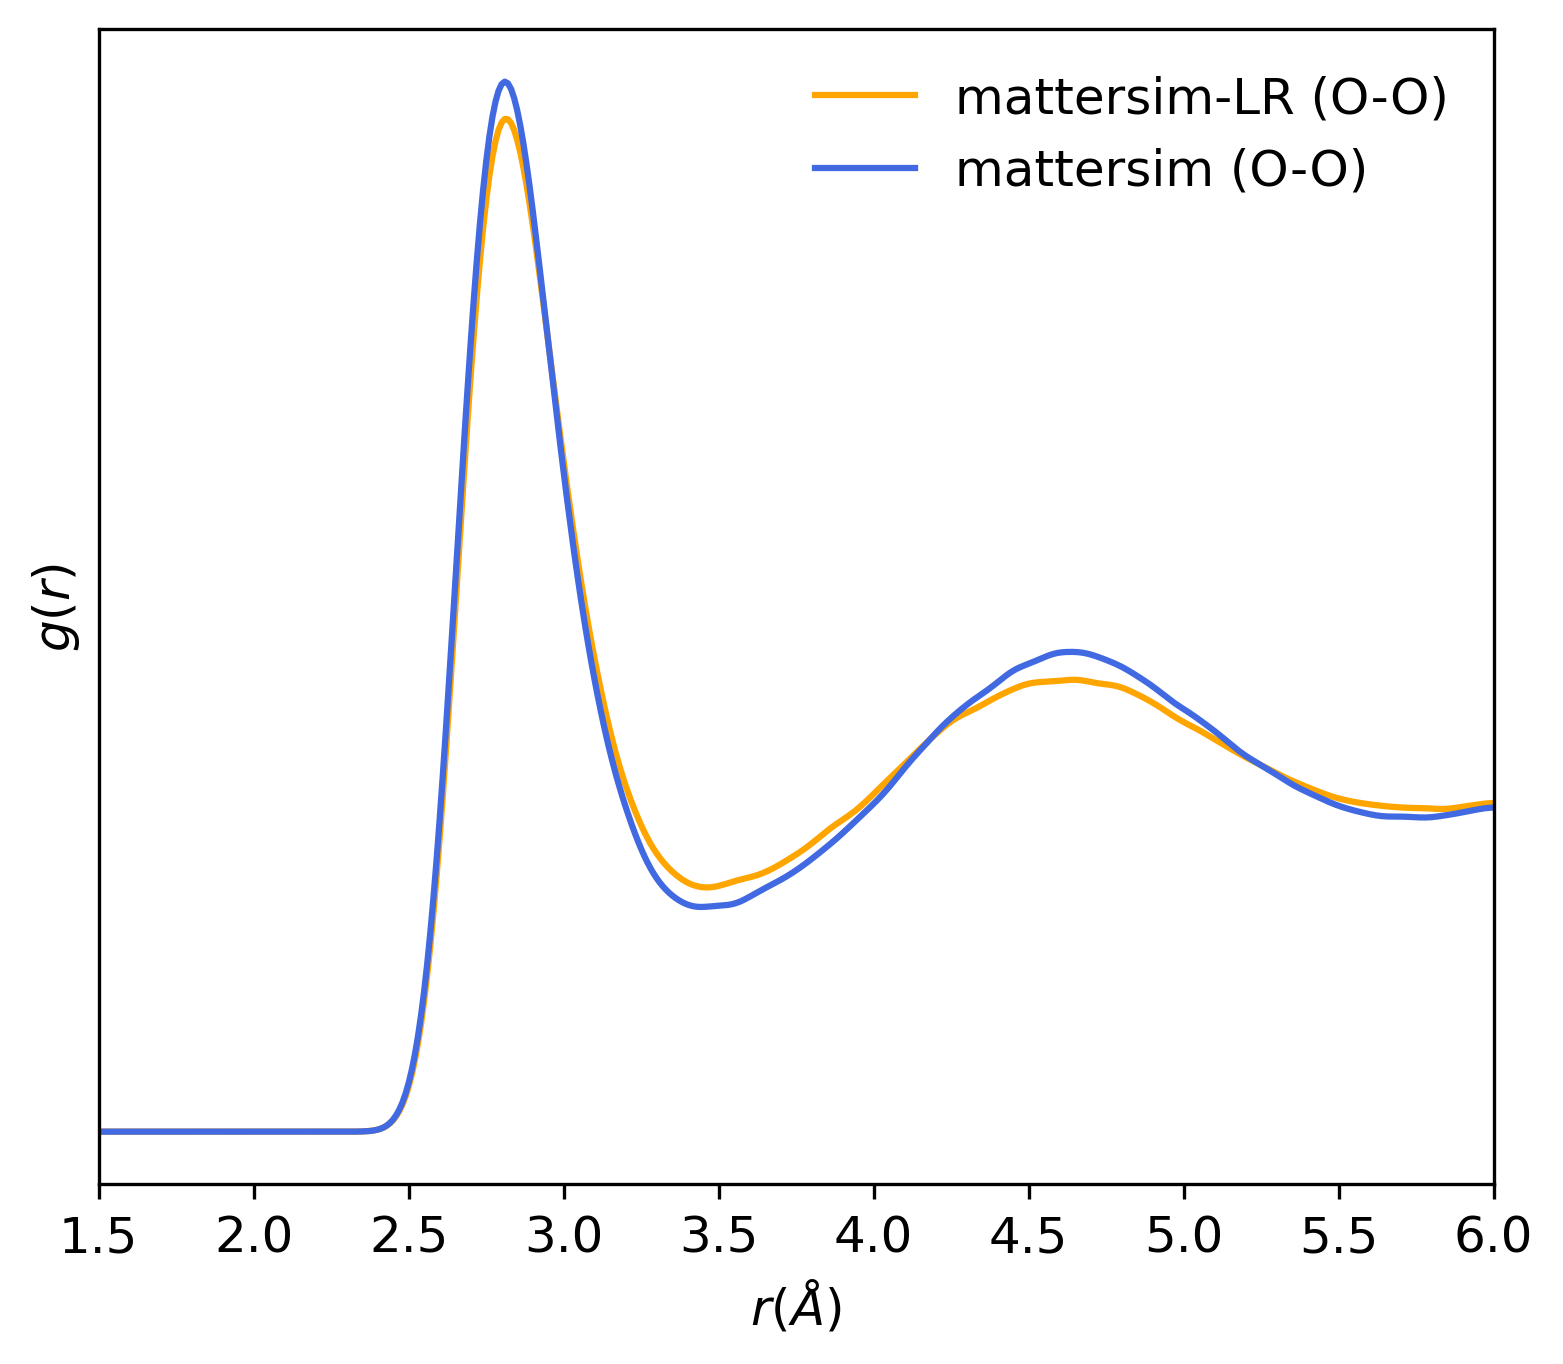

In [6]:
sigma=4

plt.figure(figsize=(6,5), dpi=300)
plt.plot(rdf_lr.index, gaussian_filter1d(rdf_lr["O O"], sigma=sigma), color='orange', label="mattersim-LR (O-O)")
plt.plot(rdf_baseline.index, gaussian_filter1d(rdf_baseline["O O"], sigma=sigma), color='royalblue', label="mattersim (O-O)")
plt.legend(frameon=False, fontsize=12)

plt.xlim([1.5, 6])
plt.ylabel(r"$g(r)$", fontsize=12)
plt.yticks([])
plt.xlabel(rf'$r (\AA)$', fontsize=12)
plt.xticks(fontsize=12)

In [ ]:
cutoff_OO = 3.4

traj = atoms_lr

frame_coord_numbers = []  

for atoms in traj:
    symbols = atoms.get_chemical_symbols()
    o_indices = [i for i, s in enumerate(symbols) if s == "O"]

    o_coord = []
    for izn in o_indices:
        dists = atoms.get_distances(izn, o_indices, mic=True)
        n_coord = np.sum(dists < cutoff_OO)
        o_coord.append(n_coord)

    frame_coord_numbers.append(np.mean(o_coord))

frame_coord_numbers = np.array(frame_coord_numbers)

# Overall average coordination number
mean_coord = np.nanmean(frame_coord_numbers)
std_coord = np.nanstd(frame_coord_numbers)

print(f"Average water–water coordination = {mean_coord:.3f} ± {std_coord:.3f}")
print(f"(Based on {len(frame_coord_numbers)} frames)")

Average Zn–water coordination = 5.129 ± 0.127
(Based on 4001 frames)
